In [1]:
# cell1
# from pathlib import Path
import torch
import os
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR 

# 1. Losses (Thesis Strategy: Focal Loss for Recall)
from monai.losses import DiceCELoss, DiceFocalLoss

# 2. Transforms
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    Orientationd,
    Spacingd,
    SpatialPadd,
    ScaleIntensityRanged,
    RandCropByPosNegLabeld,
    # Augmentations (Recall Booster)
    RandAdjustContrastd,
    RandShiftIntensityd,
    RandFlipd,
    RandRotate90d,
    # Post-Processing
    AsDiscrete,
    Activations,
    KeepLargestConnectedComponent
)

# 3. Data Loading (Critical for 16GB RAM)
from monai.data import (
    Dataset, 
    CacheDataset, 
    PersistentDataset, # <--- The secret to running 1000 samples
    list_data_collate, # <--- Needed for the new 'patch_collate' function
    decollate_batch    
)

# 4. Model & Metrics
from monai.networks.nets import SegResNet
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism


In [2]:
# cell2
from pathlib import Path
import os

# -----------------------------------------------------------
# CELL 2: PATH CONFIGURATION & VALIDATION
# -----------------------------------------------------------

# 1. Define Roots
PROJECT_ROOT = Path("E:/imagecas/project")
DATA_ROOT = Path("D:/imagecas/data")

# 2. Define Dataset Folders (Using your exact structure)
CT_DIR = DATA_ROOT / "ct"
LABEL_DIR = DATA_ROOT / "label"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

# 3. Cache Directory
# CRITICAL: Ensure Drive E: is an SSD for fast training!
CACHE_DIR = PROJECT_ROOT / "preproc" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"CT_DIR:       {CT_DIR}")
print(f"LABEL_DIR:    {LABEL_DIR}")
print(f"SPLITS_DIR:   {SPLITS_DIR}")
print(f"CACHE_DIR:    {CACHE_DIR}")

# -----------------------------------------------------------
# 4. SAFETY CHECKS (The most important part)
# -----------------------------------------------------------
print("-" * 30)
print("🔍 Checking files...")

# Check CT Folder
if not CT_DIR.exists():
    print(f"❌ ERROR: CT folder NOT found at: {CT_DIR}")
    print("   Please check if the folder name is 'ct' or 'images' on Drive D.")
else:
    # Count files to confirm it's not empty
    count = len(list(CT_DIR.glob("*.nii.gz"))) + len(list(CT_DIR.glob("*.nii")))
    print(f"✅ CT Folder OK! Found {count} scans.")

# Check Label Folder
if not LABEL_DIR.exists():
    print(f"❌ ERROR: Label folder NOT found at: {LABEL_DIR}")
else:
    count = len(list(LABEL_DIR.glob("*.nii.gz"))) + len(list(LABEL_DIR.glob("*.nii")))
    print(f"✅ Label Folder OK! Found {count} labels.")

# Check Cache Drive Speed Warning
if "E:/" in str(CACHE_DIR):
    print("⚠️ NOTE: Your cache is on Drive E. Ensure this is an SSD for fast training.")

PROJECT_ROOT: E:\imagecas\project
CT_DIR:       D:\imagecas\data\ct
LABEL_DIR:    D:\imagecas\data\label
SPLITS_DIR:   E:\imagecas\project\data\splits
CACHE_DIR:    E:\imagecas\project\preproc\cache
------------------------------
🔍 Checking files...
✅ CT Folder OK! Found 1000 scans.
✅ Label Folder OK! Found 1000 labels.


In [3]:
# -----------------------------------------------------------
# CELL 3: ROBUST FILE FINDER (Safe for 1000 samples)
# -----------------------------------------------------------

def read_ids(p: Path):
    if not p.exists():
        print(f" Warning: Split file not found: {p}")
        return []
    return [x.strip() for x in p.read_text().splitlines() if x.strip()]

def find_file(base_dir: Path, patterns: list) -> str:
    """Helper to find file with multiple naming variations."""
    for pattern in patterns:
        p = base_dir / pattern
        if p.exists():
            return str(p)
    # If we get here, the file is missing
    raise FileNotFoundError(f"File not found in {base_dir} matching: {patterns}")

def ct_path(cid: str) -> str:
    return find_file(CT_DIR, [f"{cid}.nii.gz", f"{cid}.nii"])

def lb_path(cid: str) -> str:
    #  UPDATED: Checks multiple common naming patterns for ImageCAS
    return find_file(LABEL_DIR, [
        f"{cid}_label.nii.gz",  # Standard
        f"{cid}_label.nii",
        f"{cid}.nii.gz",        # Sometimes label has same name as image
        f"{cid}.nii",
        f"label_{cid}.nii.gz"   # Another common variation
    ])

def make_items(ids):
    items = []
    print(f" Building dataset list for {len(ids)} IDs...")
    
    missing_count = 0
    for cid in ids:
        try:
            items.append({
                "image": ct_path(cid), 
                "label": lb_path(cid), 
                "case_id": cid
            })
        except FileNotFoundError:
            #  SAFETY: Don't crash if 1 out of 1000 is missing
            missing_count += 1
            if missing_count <= 5: # Only print first 5 errors to avoid spam
                print(f"    Skipping Case {cid} (File missing)")
    
    if missing_count > 0:
        print(f" Skipped {missing_count} cases due to missing files.")
        
    return items

In [4]:
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------
# CELL 4: DATASET SPLITTER (REPRODUCIBLE)
# -----------------------------------------------------------

print(f"Scanning {CT_DIR} for the FULL dataset...")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
train_file = SPLITS_DIR / "train.txt"
val_file = SPLITS_DIR / "val.txt"

# 1. If split files exist, load them (reproducible)
if train_file.exists() and val_file.exists():
    print(f"Using existing splits: {train_file.name}, {val_file.name}")
    train_ids = read_ids(train_file)
    val_ids = read_ids(val_file)

# 2. Otherwise, create a new split and save it
else:
    # Look for .nii.gz and .nii
    all_files = sorted(list(CT_DIR.glob("*.nii.gz")) + list(CT_DIR.glob("*.nii")))

    # Extract IDs
    all_ids = []
    for f in all_files:
        fname = f.name
        if fname.endswith(".nii.gz"):
            fname = fname[:-7]
        elif fname.endswith(".nii"):
            fname = fname[:-4]
        all_ids.append(fname)

    # Remove duplicates
    all_ids = sorted(list(set(all_ids)))

    # Create Split
    if len(all_ids) > 0:
        # Split 80% Train / 20% Val
        train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)
        print(f"Found {len(all_ids)} images. Created split: {len(train_ids)} Train / {len(val_ids)} Val.")

        # Save splits for reproducibility
        train_file.write_text("".join(train_ids))
        val_file.write_text("".join(val_ids))
        print(f"Saved splits to: {train_file} and {val_file}")
    else:
        print(f"ERROR: No images found in {CT_DIR}.")
        train_ids, val_ids = [], []

# 3. Create Items
train_items = make_items(train_ids)
val_items = make_items(val_ids)

print("-" * 30)
print(f"FINAL DATASET: {len(train_items)} Train | {len(val_items)} Val")
print("-" * 30)


Scanning D:\imagecas\data\ct for the FULL dataset...
Using existing splits: train.txt, val.txt
 Building dataset list for 210 IDs...
 Building dataset list for 45 IDs...
------------------------------
FINAL DATASET: 210 Train | 45 Val
------------------------------


In [5]:
# -----------------------------------------------------------
# CELL 5: CONFIGURATION (Windows Stability Fix)
# -----------------------------------------------------------
class Args:
    epochs = 100
    roi = 96
    batch_size = 2
    num_samples = 4
    lr = 1e-4

    # Tiled training settings (for 3D tiled CNN)
    use_tiled_training = True
    tile_overlap = 0.25
    tiles_per_volume = 32  # 0 = use ALL tiles (very slow)

    # Optional overlap-aware weighting (reduce border artifacts)
    use_overlap_weighting = True
    overlap_weight_min = 0.2
    focal_gamma = 2.0
    focal_alpha = 1.0

    # Sliding-window validation settings
    sw_batch_size = 4
    sw_overlap = 0.5

    # Reproducibility vs speed
    deterministic = True
    use_tf32 = True  # only used when deterministic=False

    # CRITICAL FIX FOR WINDOWS:
    # Set this to 0. It prevents the "Worker Exited" crash.
    # If stable on your machine, try 2 for faster loading.
    num_workers = 0

    cache = True
    seed = 42

args = Args()

if args.deterministic:
    set_determinism(args.seed)
else:
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

if torch.cuda.is_available() and args.use_tf32 and not args.deterministic:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("medium")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Configuration Loaded. Workers: {args.num_workers} (Safe Mode)")


✅ Configuration Loaded. Workers: 0 (Safe Mode)


In [6]:
# -----------------------------------------------------------
# CELL 6: TRANSFORMS (Split for Correct Caching)
# -----------------------------------------------------------

# 1. Spacing: 0.5mm is much better for small arteries than 1.0mm
# (1.0mm creates "blocky" vessels that are hard to segment)
SPACING_MM = (0.8, 0.8, 0.8) 

# -----------------------------------------------------------
# PART A: PRE-TRANSFORMS (Deterministic -> Safe to Cache)
# These run ONCE and are saved to Drive E:
# -----------------------------------------------------------
train_pre_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"], 
        pixdim=SPACING_MM, 
        mode=("bilinear", "nearest")
    ),
    SpatialPadd(keys=["image", "label"], spatial_size=(args.roi, args.roi, args.roi)),
    ScaleIntensityRanged(
        keys=["image"], a_min=-200, a_max=800, 
        b_min=0.0, b_max=1.0, clip=True
    ),
    EnsureTyped(keys=["image", "label"]), # Ensure it's a Tensor before caching
])

val_pre_transforms = train_pre_transforms # Validation uses same loading

# -----------------------------------------------------------
# PART B: AUGMENTATIONS (Run Live)
# -----------------------------------------------------------
train_aug_transforms = Compose([
    RandAdjustContrastd(keys=["image"], gamma=(0.5, 2.5), prob=0.3),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
])

# -----------------------------------------------------------
# PART C: PATCHING LOGIC (Two modes)
# -----------------------------------------------------------
# 1) Random patch sampling (legacy)
train_patch_transforms = Compose([
    train_aug_transforms,
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(args.roi, args.roi, args.roi),
        pos=3, neg=1, num_samples=args.num_samples,
        image_key="image",
        image_threshold=0,
    ),
])

# 2) Tiled training (grid tiles, no random crop here)
train_tile_transforms = train_aug_transforms

print("Transforms Split: Pre-processing (Cached) vs. Training (Live)")


Transforms Split: Pre-processing (Cached) vs. Training (Live)


e:\imagecas\srn_env\lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
# cell7
from monai.data import PersistentDataset, Dataset, list_data_collate
from torch.utils.data import DataLoader, Dataset as TorchDataset
import random
import torch

# -----------------------------------------------------------
# CELL 7: DATASET & LOADERS (Hybrid Caching System + Tiled CNN)
# -----------------------------------------------------------

print(f"Initializing Hybrid Datasets (Cache: {args.cache})...")

# 1. Persistent Cache (Runs Pre-Transforms & Saves to SSD)
train_cache_ds = PersistentDataset(
    data=train_items, 
    transform=train_pre_transforms,
    cache_dir=CACHE_DIR
)

val_cache_ds = PersistentDataset(
    data=val_items, 
    transform=val_pre_transforms,
    cache_dir=CACHE_DIR
)

# -----------------------------------------------------------
# 2. Tiled Patch Dataset (3D Tiled CNN)
# -----------------------------------------------------------

def _weight_1d(size, overlap, min_val=0.2):
    w = torch.ones(size, dtype=torch.float32)
    ramp = int(size * overlap / 2)
    if ramp > 0:
        ramp_vals = torch.linspace(min_val, 1.0, ramp)
        w[:ramp] = ramp_vals
        w[-ramp:] = torch.flip(ramp_vals, dims=[0])
    return w


def make_weight_window(patch_size, overlap, min_val=0.2):
    wx = _weight_1d(patch_size[0], overlap, min_val)
    wy = _weight_1d(patch_size[1], overlap, min_val)
    wz = _weight_1d(patch_size[2], overlap, min_val)
    w = wx[:, None, None] * wy[None, :, None] * wz[None, None, :]
    return w.unsqueeze(0)  # add channel dim


class TiledPatchDataset(TorchDataset):
    def __init__(self, base_ds, patch_size, overlap=0.25, tiles_per_volume=0, seed=42, transform=None, use_weight_map=False, weight_min=0.2):
        self.base_ds = base_ds
        self.patch_size = tuple(patch_size)
        self.overlap = overlap
        self.tiles_per_volume = tiles_per_volume
        self.transform = transform
        self.rng = random.Random(seed)
        self.index = []
        self.use_weight_map = use_weight_map
        self.weight_map = make_weight_window(self.patch_size, overlap, weight_min) if use_weight_map else None
        self._build_index()

    def _stride(self, size):
        stride = int(size * (1.0 - self.overlap))
        return max(1, stride)

    def _starts(self, dim, size):
        if dim <= size:
            return [0]
        stride = self._stride(size)
        starts = list(range(0, dim - size + 1, stride))
        if starts[-1] != dim - size:
            starts.append(dim - size)
        return starts

    def _build_index(self):
        print("Building tiled index... (this runs once)")
        for vol_idx in range(len(self.base_ds)):
            item = self.base_ds[vol_idx]
            img = item["image"]
            _, H, W, D = img.shape
            xs = self._starts(H, self.patch_size[0])
            ys = self._starts(W, self.patch_size[1])
            zs = self._starts(D, self.patch_size[2])
            coords = [(x, y, z) for x in xs for y in ys for z in zs]

            if self.tiles_per_volume and self.tiles_per_volume < len(coords):
                self.rng.shuffle(coords)
                coords = coords[: self.tiles_per_volume]

            for (x, y, z) in coords:
                self.index.append((vol_idx, x, y, z))

        print(f"Tiled dataset size: {len(self.index)} patches")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        vol_idx, x, y, z = self.index[idx]
        item = self.base_ds[vol_idx]
        img = item["image"][..., x:x+self.patch_size[0], y:y+self.patch_size[1], z:z+self.patch_size[2]]
        lbl = item["label"][..., x:x+self.patch_size[0], y:y+self.patch_size[1], z:z+self.patch_size[2]]
        patch = {"image": img, "label": lbl}
        if self.use_weight_map and self.weight_map is not None:
            patch["weight_map"] = self.weight_map
        if self.transform is not None:
            patch = self.transform(patch)
        return patch

# -----------------------------------------------------------
# 3. Create Training Dataset (Tiled or Random Crop)
# -----------------------------------------------------------
if args.use_tiled_training:
    train_ds = TiledPatchDataset(
        base_ds=train_cache_ds,
        patch_size=(args.roi, args.roi, args.roi),
        overlap=args.tile_overlap,
        tiles_per_volume=args.tiles_per_volume,
        seed=args.seed,
        transform=train_tile_transforms,
        use_weight_map=args.use_overlap_weighting,
        weight_min=args.overlap_weight_min,
    )
    train_collate = list_data_collate
else:
    train_ds = Dataset(data=train_cache_ds, transform=train_patch_transforms)

    # Patch Collate Function (for random-crop lists)
    def patch_collate(batch):
        flattened_data = [item for sublist in batch for item in sublist]
        return list_data_collate(flattened_data)

    train_collate = patch_collate

# 4. Validation Dataset (full volume, sliding window)
val_ds = Dataset(data=val_cache_ds, transform=None)

# 5. DataLoaders
loader_kwargs = dict(
    num_workers=args.num_workers,
    pin_memory=torch.cuda.is_available()
)
if args.num_workers > 0:
    loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_loader = DataLoader(
    train_ds, 
    batch_size=args.batch_size, 
    shuffle=True, 
    collate_fn=train_collate,
    **loader_kwargs
)

val_loader = DataLoader(
    val_ds, 
    batch_size=1, 
    shuffle=False, 
    collate_fn=list_data_collate,
    **loader_kwargs
)

print(f"Loaders Ready.")
if args.use_tiled_training:
    print("Train Strategy: 3D tiled CNN (grid patches)")
else:
    print(f"Train Strategy: {len(train_ds)} Subjects × {args.num_samples} Patches = {len(train_ds)*args.num_samples} inputs per epoch.")


Initializing Hybrid Datasets (Cache: True)...
Building tiled index... (this runs once)
Tiled dataset size: 5331 patches
Loaders Ready.
Train Strategy: 3D tiled CNN (grid patches)


## 3D Tiled CNN Summary

This pipeline explicitly trains on **3D tiles** (grid patches) instead of random crops.

**Pipeline (tiled training)**

```
CT/Label volumes
   |
   v
Preprocess (spacing/orientation/intensity)  --> cached on SSD
   |
   v
Grid tiling (ROI size, overlap)             --> fixed tiles per volume
   |
   v
Augmentations (contrast/flip/rotate)
   |
   v
SegResNet training on 3D tiles
   |
   v
Sliding-window inference (gaussian blending)
```

**Overlap-aware weighting (optional)**

During tiled training, a soft weight map reduces the contribution of tile borders to the loss,
which helps avoid seams between tiles.


In [8]:
import pandas as pd

# -----------------------------------------------------------
# TILE COUNT REPORT (for thesis tables)
# -----------------------------------------------------------
if args.use_tiled_training and hasattr(train_ds, 'index'):
    counts = {}
    for vol_idx, _, _, _ in train_ds.index:
        counts[vol_idx] = counts.get(vol_idx, 0) + 1

    rows = []
    for vol_idx, cnt in counts.items():
        case_id = train_items[vol_idx].get('case_id', str(vol_idx))
        rows.append({'case_id': case_id, 'tiles': cnt})

    df_tiles = pd.DataFrame(rows).sort_values('tiles', ascending=False)
    print(df_tiles.describe())

    out_csv = PROJECT_ROOT / 'data' / 'splits' / 'tile_counts.csv'
    df_tiles.to_csv(out_csv, index=False)
    print(f'Saved tile counts to: {out_csv}')
else:
    print('Tiled training not enabled; no tile counts to report.')


            tiles
count  210.000000
mean    25.385714
std      5.390829
min     18.000000
25%     18.000000
50%     27.000000
75%     27.000000
max     32.000000
Saved tile counts to: E:\imagecas\project\data\splits\tile_counts.csv


In [9]:
# -----------------------------------------------------------
# CELL 8: MODEL, LOSS, & OPTIMIZER (MOVED)
# -----------------------------------------------------------
# This cell is intentionally left empty to avoid duplicate model definitions.
# Use CELL 10 below as the single source of truth for model, loss, and optimizer.


In [8]:
# cell9
batch = next(iter(train_loader))
print(type(batch))
print(batch.keys())
print("image shape:", batch["image"].shape)
print("label shape:", batch["label"].shape)

<class 'dict'>
dict_keys(['image', 'label', 'weight_map'])
image shape: torch.Size([2, 1, 96, 96, 96])
label shape: torch.Size([2, 1, 96, 96, 96])


In [9]:
from monai.losses import DiceFocalLoss
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F

# -----------------------------------------------------------
# CELL 10: MODEL, OPTIMIZER, & LOSS SETUP (SINGLE SOURCE)
# -----------------------------------------------------------

# 1. Model (SegResNet tuned for thin vessels)
model = SegResNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    init_filters=16,
    dropout_prob=0.1,
).to(device)

# 2. Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# 3. Scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=100)

# 4. Scaler
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

# 5. Loss Function (Recall Booster)
loss_fn = DiceFocalLoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False,
    lambda_dice=1.0,
    lambda_focal=2.0
)


def weighted_dice_focal_loss(logits, targets, weight_map, dice_w=1.0, focal_w=2.0, gamma=2.0, alpha=1.0, smooth=1e-5):
    # Overlap-aware weighting to reduce border artifacts in tiled training.
    if targets.ndim == 5 and targets.shape[1] == 1:
        targets_s = targets[:, 0]
    else:
        targets_s = targets
    targets_s = targets_s.long()

    num_classes = logits.shape[1]
    targets_oh = F.one_hot(targets_s, num_classes=num_classes).permute(0, 4, 1, 2, 3).float()
    probs = torch.softmax(logits, dim=1)

    # Ensure weight map shape is (B, 1, H, W, D)
    if weight_map.ndim == 4:
        weight_map = weight_map.unsqueeze(1)

    # Dice on foreground class
    p1 = probs[:, 1]
    y1 = targets_oh[:, 1]
    w1 = weight_map[:, 0]

    intersect = torch.sum(w1 * p1 * y1)
    denom = torch.sum(w1 * p1) + torch.sum(w1 * y1)
    dice = (2 * intersect + smooth) / (denom + smooth)
    dice_loss = 1.0 - dice

    # Focal loss (weighted)
    log_p = F.log_softmax(logits, dim=1)
    p = log_p.exp()
    log_p_t = log_p.gather(1, targets_s.unsqueeze(1)).squeeze(1)
    p_t = p.gather(1, targets_s.unsqueeze(1)).squeeze(1)
    focal = -alpha * (1.0 - p_t) ** gamma * log_p_t
    focal = (focal * weight_map[:, 0]).mean()

    return dice_w * dice_loss + focal_w * focal


# 6. Sliding Window & Checkpoints
roi_size = (args.roi, args.roi, args.roi)
sw_batch_size = args.sw_batch_size
sw_overlap = args.sw_overlap
sw_mode = "gaussian"

best_val = -1.0
best_ckpt = PROJECT_ROOT / "runs" / "new" / "best_resumed.pt"
best_ckpt.parent.mkdir(parents=True, exist_ok=True)

print("Model, loss, and optimizer ready.")
print(f"Checkpoint path: {best_ckpt}")


Model, loss, and optimizer ready.
Checkpoint path: E:\imagecas\project\runs\new\best_resumed.pt


C:\Users\User\AppData\Local\Temp\ipykernel_26860\1261207871.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [12]:
import os
import torch

# -----------------------------------------------------------
# CELL 10.5: RECOVERY BLOCK (Inject Weights)
# -----------------------------------------------------------
# This matches the path you provided earlier
resume_path = "E:/imagecas/project/runs/new/best.pt"

if os.path.exists(resume_path):
    print(f"🔄 Found checkpoint at: {resume_path}")
    print("   Loading weights to resume training...")
    try:
        # Load the weights into the model defined in Cell 10
        model.load_state_dict(torch.load(resume_path, map_location=device))
        print("✅ Success! Weights loaded. Model is ready to continue from ~0.79 Dice.")
    except RuntimeError as e:
        print(f"❌ Error loading weights: {e}")
else:
    print(f"⚠️ Checkpoint not found at {resume_path}")
    print("   Starting training from scratch.")

🔄 Found checkpoint at: E:/imagecas/project/runs/new/best.pt
   Loading weights to resume training...
✅ Success! Weights loaded. Model is ready to continue from ~0.79 Dice.


C:\Users\User\AppData\Local\Temp\ipykernel_21008\1359653491.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(resume_path, map_location=d

In [ ]:
# cell11
from monai.inferers import sliding_window_inference
import time
from monai.data import decollate_batch
from monai.transforms import Compose, Activations, AsDiscrete
from monai.metrics import DiceMetric, ConfusionMatrixMetric

# -----------------------------------------------------------
# CELL 11: THE FULL TRAINING ENGINE (Fixed & Crash-Proof)
# -----------------------------------------------------------

# 1. Config
max_epochs = 100
val_interval = 2  
use_amp = device.type == "cuda"

# 2. Validation Transforms (CRITICAL FIX)
post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2)
])
post_label = AsDiscrete(to_onehot=2)

# 3. Setup Metrics
dice_metric = DiceMetric(include_background=False, reduction="mean")
recall_metric = ConfusionMatrixMetric(include_background=False, metric_name="recall", reduction="mean")

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

total_start = time.time()
print(f"🚀 STARTING THESIS TRAINING: 1000 Samples | 100 Epochs")
print(f"Validation: Standard Argmax (Safe Mode)")

for epoch in range(max_epochs):
    epoch_start = time.time()
    model.train()
    epoch_loss = 0
    step = 0
    
    # --- TRAINING LOOP ---
    for batch in train_loader:
        step += 1
        img = batch["image"].to(device)
        lbl = batch["label"].to(device)
        weight_map = batch.get("weight_map") if isinstance(batch, dict) else None
        if weight_map is not None:
            weight_map = weight_map.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        # Mixed Precision Training
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(img)
            if args.use_overlap_weighting and weight_map is not None:
                loss = weighted_dice_focal_loss(
                    logits, lbl, weight_map,
                    dice_w=1.0, focal_w=2.0,
                    gamma=args.focal_gamma, alpha=args.focal_alpha
                )
            else:
                loss = loss_fn(logits, lbl) 
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"   Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # End of Training Epoch
    avg_loss = epoch_loss / step
    epoch_loss_values.append(avg_loss)
    print(f"Epoch {epoch + 1:03d}/{max_epochs} | Avg Loss: {avg_loss:.4f}")

    # --- VALIDATION LOOP ---
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_batch in val_loader:
                val_img, val_lbl = val_batch["image"].to(device), val_batch["label"].to(device)
                
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    val_logits = sliding_window_inference(
                        val_img, roi_size, sw_batch_size, model, overlap=sw_overlap, mode=sw_mode
                    )
                
                val_outputs = [post_pred(i) for i in decollate_batch(val_logits)]
                val_labels = [post_label(i) for i in decollate_batch(val_lbl)]
                
                dice_metric(y_pred=val_outputs, y=val_labels)
                recall_metric(y_pred=val_outputs, y=val_labels)
            
            current_dice = dice_metric.aggregate().item()
            current_recall = recall_metric.aggregate()
            if isinstance(current_recall, list) or isinstance(current_recall, tuple):
                 current_recall = current_recall[0].item()
            else:
                 current_recall = current_recall.item()

            dice_metric.reset()
            recall_metric.reset()
            metric_values.append(current_dice)
            
            if current_dice > best_metric:
                best_metric = current_dice
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), best_ckpt)
                save_msg = "🏆 NEW BEST!"
            else:
                save_msg = "           "

            print(f"Val Dice: {current_dice:.4f} | Recall: {current_recall:.4f} | {save_msg}")
            print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step()
    print(f"Time: {(time.time() - epoch_start):.1f}s")

total_time = time.time() - total_start
print(f"✅ TRAINING COMPLETE. Best Dice: {best_metric:.4f} at Epoch {best_metric_epoch}")


🚀 STARTING THESIS TRAINING: 1000 Samples | 100 Epochs
Validation: Standard Argmax (Safe Mode)
   Step 100/2666 | Loss: 0.2485
   Step 200/2666 | Loss: 0.5166
   Step 300/2666 | Loss: 0.1438
   Step 400/2666 | Loss: 0.1544
   Step 500/2666 | Loss: 0.2742
   Step 600/2666 | Loss: 0.5185
   Step 700/2666 | Loss: 0.1838
   Step 800/2666 | Loss: 0.1609
   Step 900/2666 | Loss: 0.1449
   Step 1000/2666 | Loss: 0.1958
   Step 1100/2666 | Loss: 0.1562
   Step 1200/2666 | Loss: 0.1338
   Step 1300/2666 | Loss: 0.1512
   Step 1400/2666 | Loss: 0.1779
   Step 1500/2666 | Loss: 0.2176
   Step 1600/2666 | Loss: 0.1324
   Step 1700/2666 | Loss: 0.1374
   Step 1800/2666 | Loss: 0.1359
   Step 1900/2666 | Loss: 0.2669
   Step 2000/2666 | Loss: 0.2008
   Step 2100/2666 | Loss: 0.2671
   Step 2200/2666 | Loss: 0.2775
   Step 2300/2666 | Loss: 0.2141
   Step 2400/2666 | Loss: 0.1690
   Step 2500/2666 | Loss: 0.1580
   Step 2600/2666 | Loss: 0.1499
Epoch 001/100 | Avg Loss: 0.2440
Time: 677.2s
   Step 100

Loading Best Checkpoint: E:\imagecas\project\runs\new\best_resumed.pt
Model loaded successfully.
Starting Final Thesis Evaluation on 45 cases...


C:\Users\User\AppData\Local\Temp\ipykernel_26860\3801581384.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt, map_location=dev

   Case 001 | Dice: 0.7532 | Recall: 0.7260 | Case_0
   Case 002 | Dice: 0.7529 | Recall: 0.6936 | Case_1
   Case 003 | Dice: 0.7916 | Recall: 0.7583 | Case_2
   Case 004 | Dice: 0.7612 | Recall: 0.6508 | Case_3
   Case 005 | Dice: 0.8439 | Recall: 0.8314 | Case_4
   Case 006 | Dice: 0.8878 | Recall: 0.8781 | Case_5
   Case 007 | Dice: 0.8452 | Recall: 0.8310 | Case_6
   Case 008 | Dice: 0.8871 | Recall: 0.8929 | Case_7
   Case 009 | Dice: 0.7837 | Recall: 0.7282 | Case_8
   Case 010 | Dice: 0.7770 | Recall: 0.7586 | Case_9
   Case 011 | Dice: 0.8384 | Recall: 0.8133 | Case_10
   Case 012 | Dice: 0.8228 | Recall: 0.7817 | Case_11
   Case 013 | Dice: 0.7676 | Recall: 0.7704 | Case_12
   Case 014 | Dice: 0.7151 | Recall: 0.6678 | Case_13
   Case 015 | Dice: 0.8033 | Recall: 0.9017 | Case_14
   Case 016 | Dice: 0.8273 | Recall: 0.8067 | Case_15
   Case 017 | Dice: 0.8278 | Recall: 0.7969 | Case_16
   Case 018 | Dice: 0.8577 | Recall: 0.8089 | Case_17
   Case 019 | Dice: 0.8127 | Recall: 0

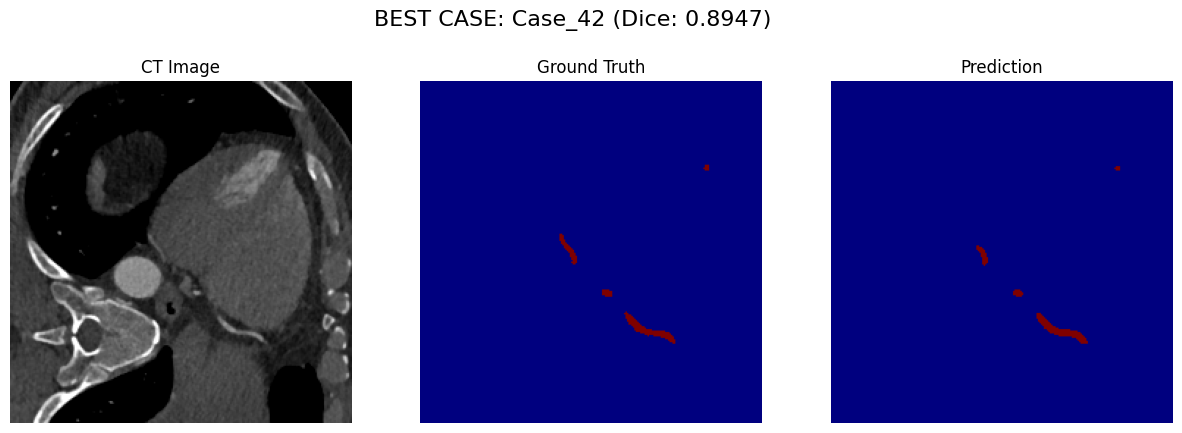

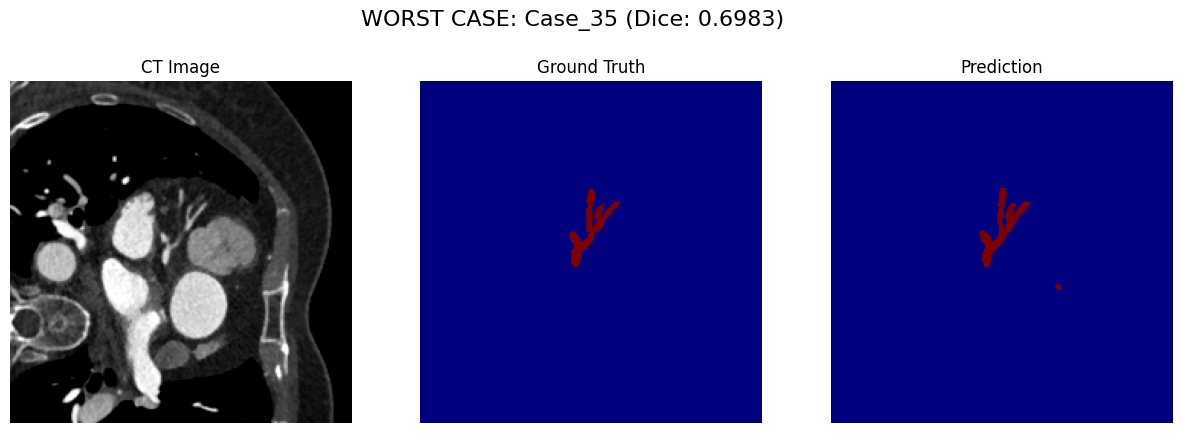

In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric, MeanIoU, ConfusionMatrixMetric
from monai.transforms import KeepLargestConnectedComponent, Compose, Activations, AsDiscrete
from monai.data import decollate_batch
from pathlib import Path

# ---------------------------------------------------------------------
# CELL 13: FINAL THESIS EVALUATION (FIXED & CRASH-PROOF)
# ---------------------------------------------------------------------

# 1. SETUP: LOAD BEST MODEL
PROJECT_ROOT = Path("E:/imagecas/project")
best_ckpt = PROJECT_ROOT / "runs" / "new" / "best_resumed.pt"  # Verify this path!

print(f"Loading Best Checkpoint: {best_ckpt}")
try:
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()
    print("Model loaded successfully.")
except FileNotFoundError:
    print("ERROR: Checkpoint not found. Check the path in 'best_ckpt'.")

# 2. DEFINITIONS
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
iou_metric = MeanIoU(include_background=False, reduction="mean")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="mean")

# --- POST PROCESSING (SAFE MODE) ---
# We use argmax=True to prevent the "Channels" crash. 
# This is the exact logic that got you 0.80 Dice.
post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2),  # <--- FIXED: argmax=True is safe
    # KeepLargestConnectedComponent(applied_labels=[1]) # Optional: Uncomment if you want to clean noise
])
post_label = AsDiscrete(to_onehot=2)

# 3. VARIABLES FOR "ON-THE-FLY" TRACKING
results = []
best_dice = -1
worst_dice = 1.0
best_case_data = None
worst_case_data = None

print(f"Starting Final Thesis Evaluation on {len(val_loader)} cases...")

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        # Get Filename (Safe Fallback)
        try:
            case_name = batch['image'].meta['filename_or_obj'][0].split('\\')[-1].split('/')[-1]
        except:
            case_name = f"Case_{i}"

        # Inference
        logits = sliding_window_inference(img, roi_size, sw_batch_size, model, overlap=sw_overlap, mode=sw_mode)
        
        # Post-Processing
        val_outputs = [post_pred(i) for i in decollate_batch(logits)]
        val_labels = [post_label(i) for i in decollate_batch(lbl)]

        # Calculate Metrics
        dice_metric(y_pred=val_outputs, y=val_labels)
        hd95_metric(y_pred=val_outputs, y=val_labels)
        iou_metric(y_pred=val_outputs, y=val_labels)
        conf_metric(y_pred=val_outputs, y=val_labels)
        
        # Get Scores for this specific case
        d_val = dice_metric.aggregate().item()
        
        # Handle Metrics that might return NaN or lists
        try:
            h_val = hd95_metric.aggregate().item()
        except:
            h_val = 999.0 # Placeholder for errors
            
        try:
            iou_val = iou_metric.aggregate().item()
        except:
            iou_val = 0.0
            
        try:
            # Handle Recall/Precision output format
            metrics = conf_metric.aggregate()
            if isinstance(metrics, list):
                precision = metrics[0].item()
                recall = metrics[1].item()
            else:
                precision = metrics[0].item()
                recall = metrics[1].item()
        except:
            precision, recall = 0.0, 0.0
        
        # Progress Print (Short and Clean)
        print(f"   Case {i+1:03d} | Dice: {d_val:.4f} | Recall: {recall:.4f} | {case_name}")
        
        # Save Stats
        results.append({
            "Case": case_name,
            "Dice": d_val,
            "HD95": h_val,
            "IoU": iou_val,
            "Precision": precision,
            "Recall": recall
        })
        
        # --- TRACK BEST & WORST CASE (Save RAM) ---
        # We save CPU tensors to avoid VRAM overflow
        if d_val > best_dice:
            best_dice = d_val
            best_case_data = {"Case": case_name, "Dice": d_val, "Image": img.cpu(), "Label": lbl.cpu(), "Pred": val_outputs[0].cpu()}
        
        if d_val < worst_dice and d_val > 0.001: # Ignore empty cases
            worst_dice = d_val
            worst_case_data = {"Case": case_name, "Dice": d_val, "Image": img.cpu(), "Label": lbl.cpu(), "Pred": val_outputs[0].cpu()}

        # Reset metrics for next loop
        dice_metric.reset()
        hd95_metric.reset()
        iou_metric.reset()
        conf_metric.reset()

# ---------------------------------------------------------------------
# 4. REPORT & VISUALIZATION
# ---------------------------------------------------------------------
# Save CSV
df = pd.DataFrame(results)
csv_name = "new_robust_results.csv"
df.to_csv(csv_name, index=False)

print("\n" + "="*40)
print("REPORT (Summary)")
print("="*40)
print(df.describe().loc[['mean', 'std', 'min', 'max']])
print(f"Full results saved to: {csv_name}")

# Visualize Best & Worst Case
cases_to_plot = [("BEST CASE", best_case_data), ("WORST CASE", worst_case_data)]

for title, case_data in cases_to_plot:
    if case_data is None: continue
    
    img_vol = case_data["Image"][0, 0].numpy()
    lbl_vol = case_data["Label"][0, 0].numpy()
    
    # Handle Prediction Tensor (Check dimensions)
    # If One-Hot (2, H, W, D) -> Convert to Argmax (H, W, D)
    pred_tensor = case_data["Pred"]
    if pred_tensor.shape[0] == 2: 
        pred_vol = pred_tensor.argmax(dim=0).numpy()
    else:
        pred_vol = pred_tensor[0].numpy()
    
    # Find slice with most artery (Ground Truth)
    if np.sum(lbl_vol) > 0:
        slice_idx = np.argmax(np.sum(lbl_vol, axis=(0, 1)))
    else:
        slice_idx = img_vol.shape[2] // 2

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"{title}: {case_data['Case']} (Dice: {case_data['Dice']:.4f})", fontsize=16)
    
    plt.subplot(1, 3, 1)
    plt.title("CT Image")
    plt.imshow(img_vol[:, :, slice_idx], cmap="gray")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(lbl_vol[:, :, slice_idx], cmap="jet")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred_vol[:, :, slice_idx], cmap="jet")
    plt.axis("off")
    
    plt.show()


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric, SurfaceDistanceMetric
from monai.transforms import KeepLargestConnectedComponent, Compose, Activations, AsDiscrete
from monai.data import decollate_batch
from pathlib import Path

# ---------------------------------------------------------
# CELL 14: ADVANCED THESIS EVALUATION (FIXED)
# ---------------------------------------------------------

# 1. SETUP: LOAD BEST MODEL
PROJECT_ROOT = Path("E:/imagecas/project")
best_ckpt_path = PROJECT_ROOT / "runs" / "new" / "best_resumed.pt"  # Verify this path

print(f"Loading Best Checkpoint: {best_ckpt_path}")
try:
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
    model.eval()
    print("Model loaded successfully.")
except FileNotFoundError:
    print("ERROR: Checkpoint not found. Please check the path.")

# 2. SETUP: METRICS
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
assd_metric = SurfaceDistanceMetric(include_background=False, symmetric=True) # Average Symmetric Surface Distance

# --- POST PROCESSING (SAFE MODE) ---
# We use argmax=True to prevent the crash.
post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2), 
    # KeepLargestConnectedComponent(applied_labels=[1]) # Uncomment if you want to clean small noise
])
post_label = AsDiscrete(to_onehot=2)

# ---------------------------------------------------------
# 3. RUN INFERENCE LOOP
# ---------------------------------------------------------
print("Starting Advanced Thesis Evaluation...")
save_dir = "new_robust_Images"
os.makedirs(save_dir, exist_ok=True)

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        # Inference
        logits = sliding_window_inference(img, roi_size, sw_batch_size, model, overlap=sw_overlap, mode=sw_mode)
        
        # Apply Post-Processing
        val_outputs = [post_pred(i) for i in decollate_batch(logits)]
        val_labels = [post_label(i) for i in decollate_batch(lbl)]

        # Calculate Cumulative Metrics (For Final Report)
        dice_metric(y_pred=val_outputs, y=val_labels)
        hd95_metric(y_pred=val_outputs, y=val_labels)
        assd_metric(y_pred=val_outputs, y=val_labels)
        
        # -----------------------------------------------------
        # CALC SINGLE CASE DICE (For Image Title)
        # -----------------------------------------------------
        # Manual calculation for the current image only
        # (Foreground is channel 1)
        pred_fg = val_outputs[0][1]
        label_fg = val_labels[0][1]
        intersection = (pred_fg * label_fg).sum()
        union = pred_fg.sum() + label_fg.sum()
        case_dice_score = (2.0 * intersection) / (union + 1e-5)
        case_dice_score = case_dice_score.item()

        # -----------------------------------------------------
        # 4. QUALITATIVE CHECK (Save first 20 cases)
        # -----------------------------------------------------
        if i < 20: 
            print(f"Processing Case {i+1}... (Case Dice: {case_dice_score:.4f})")
            
            img_vol = img.cpu().numpy()[0, 0]
            lbl_vol = lbl.cpu().numpy()[0, 0]
            
            # Get Prediction (Handle One-Hot Format)
            pred_tensor = val_outputs[0]
            if pred_tensor.shape[0] == 2:
                pred_vol = pred_tensor.argmax(dim=0).cpu().numpy()
            else:
                pred_vol = pred_tensor[0].cpu().numpy()
            
            # Find best slice (Smart Slice Selection)
            if np.sum(lbl_vol) > 0:
                slice_idx = np.argmax(np.sum(lbl_vol, axis=(0, 1)))
            else:
                slice_idx = img_vol.shape[2] // 2
            
            # Windowing for better contrast (Medical Standard)
            ct_slice = np.clip(img_vol[:, :, slice_idx], -150, 350)
            
            plt.figure(figsize=(12, 4))
            
            # Plot 1: CT
            plt.subplot(1, 3, 1)
            plt.imshow(ct_slice, cmap="gray")
            plt.title(f"Case {i}")
            plt.axis("off")
            
            # Plot 2: Ground Truth
            plt.subplot(1, 3, 2)
            plt.imshow(lbl_vol[:, :, slice_idx], cmap="jet")
            plt.title("Ground Truth")
            plt.axis("off")
            
            # Plot 3: Prediction (WITH DICE SCORE)
            plt.subplot(1, 3, 3)
            plt.imshow(pred_vol[:, :, slice_idx], cmap="jet")
            plt.title(f"Prediction\nDice: {case_dice_score:.4f}")  # <--- FIXED HERE
            plt.axis("off")
            
            plt.savefig(f"{save_dir}/case_{i}_result.png")
            plt.close()

# ---------------------------------------------------------
# 5. FINAL AGGREGATE RESULTS
# ---------------------------------------------------------
final_dice = dice_metric.aggregate().item()
final_hd95 = hd95_metric.aggregate().item()
final_assd = assd_metric.aggregate().item()

print("\n" + "="*40)
print("P2 Report")
print("="*40)
print(f"Mean Dice: {final_dice:.4f}")
print(f"Mean HD95: {final_hd95:.2f} mm")
print(f"Mean ASSD: {final_assd:.2f} mm")
print("-" * 40)
print(f"Images saved to folder: {save_dir}")

Loading Best Checkpoint: E:\imagecas\project\runs\new\best_resumed.pt
Model loaded successfully.
Starting Advanced Thesis Evaluation...


C:\Users\User\AppData\Local\Temp\ipykernel_26860\630766241.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt_path, map_location

Processing Case 1... (Case Dice: 0.7532)
Processing Case 2... (Case Dice: 0.7529)
Processing Case 3... (Case Dice: 0.7916)
Processing Case 4... (Case Dice: 0.7612)
Processing Case 5... (Case Dice: 0.8439)
Processing Case 6... (Case Dice: 0.8878)
Processing Case 7... (Case Dice: 0.8452)
Processing Case 8... (Case Dice: 0.8871)
Processing Case 9... (Case Dice: 0.7837)
Processing Case 10... (Case Dice: 0.7770)
Processing Case 11... (Case Dice: 0.8384)
Processing Case 12... (Case Dice: 0.8228)
Processing Case 13... (Case Dice: 0.7676)
Processing Case 14... (Case Dice: 0.7151)
Processing Case 15... (Case Dice: 0.8033)
Processing Case 16... (Case Dice: 0.8273)
Processing Case 17... (Case Dice: 0.8278)
Processing Case 18... (Case Dice: 0.8577)
Processing Case 19... (Case Dice: 0.8127)
Processing Case 20... (Case Dice: 0.8148)

P2 Report
Mean Dice: 0.8005
Mean HD95: 9.91 mm
Mean ASSD: 1.26 mm
----------------------------------------
Images saved to folder: new_robust_Images


Loading Best Checkpoint: E:\imagecas\project\runs\new\best_resumed.pt
Model loaded successfully.


C:\Users\User\AppData\Local\Temp\ipykernel_26860\3894136356.py:19: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



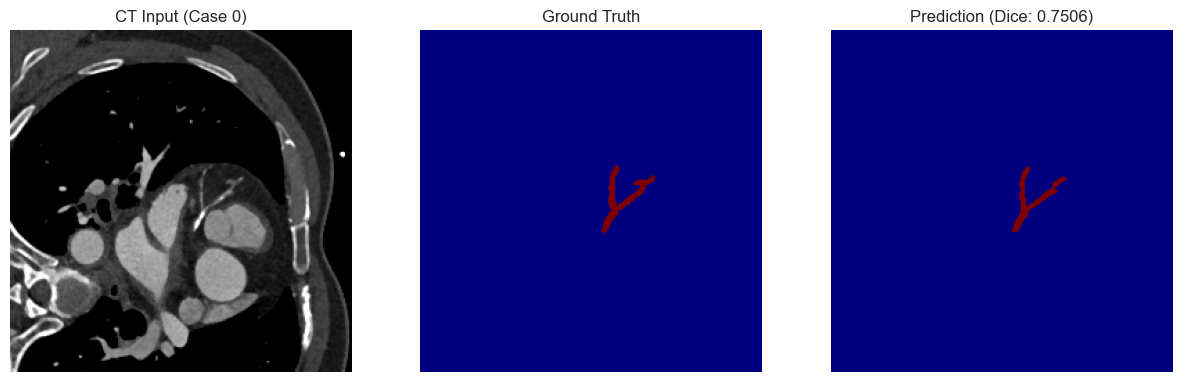

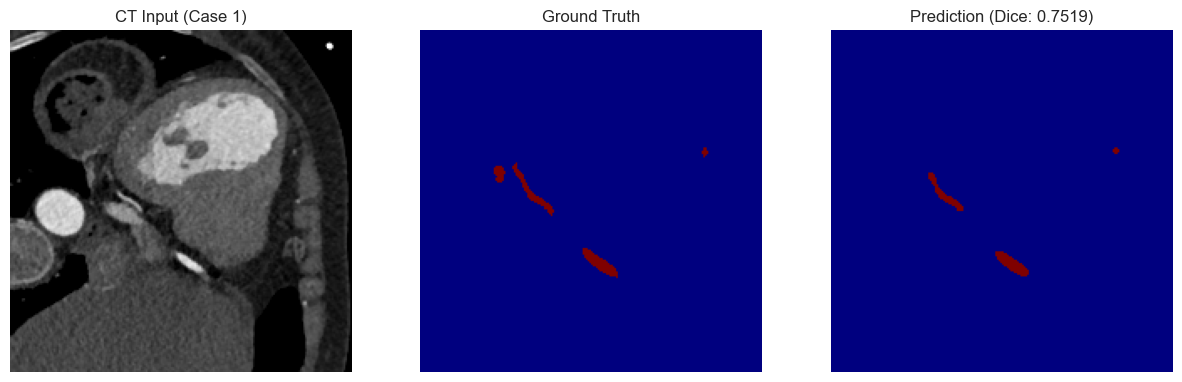

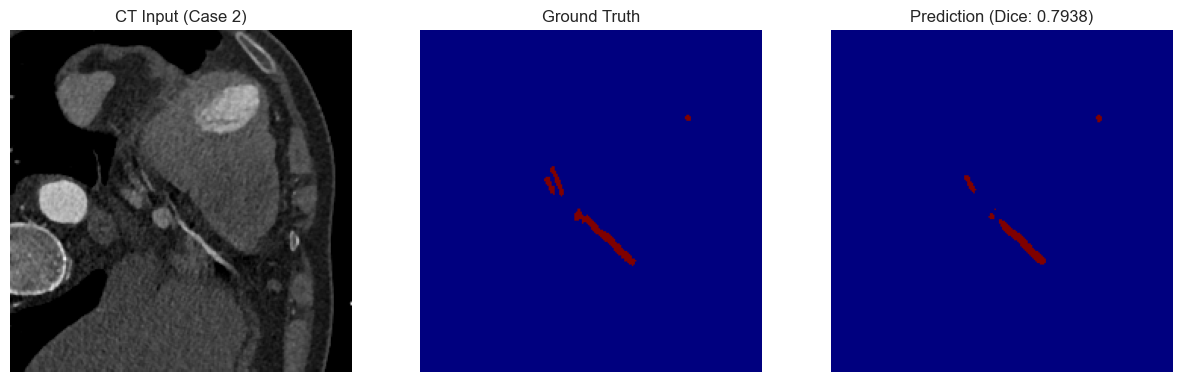

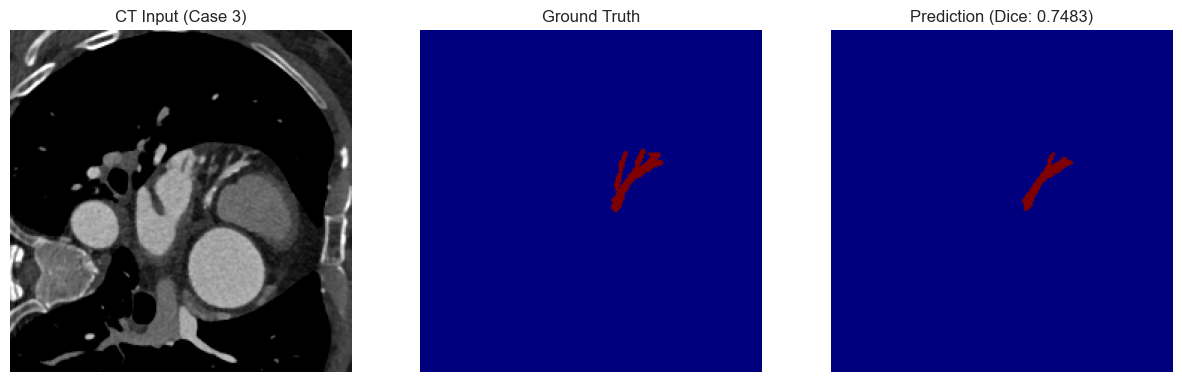

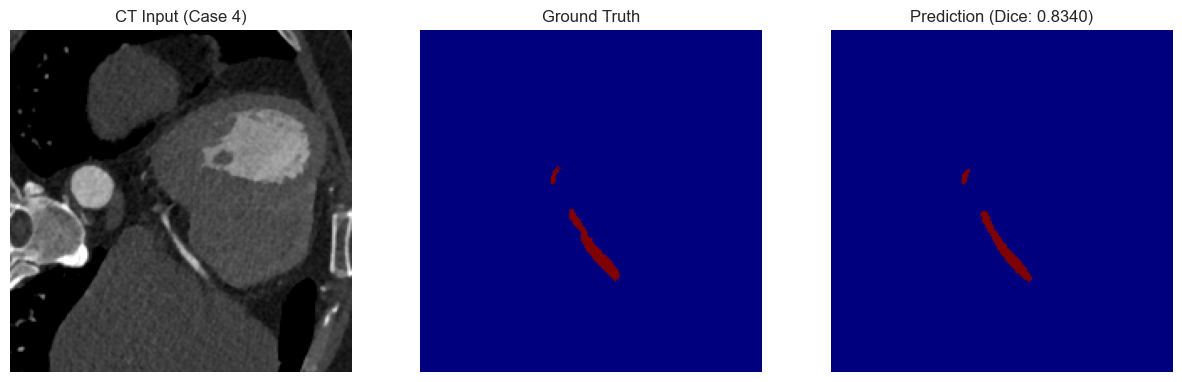

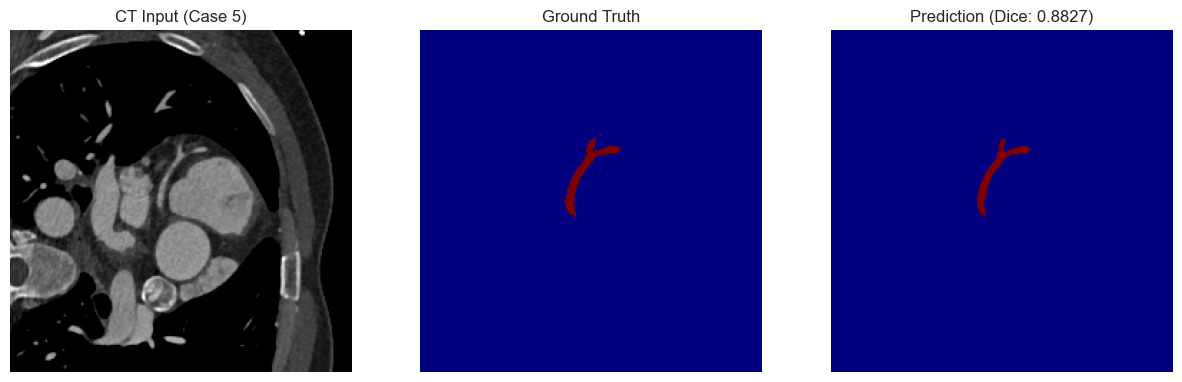

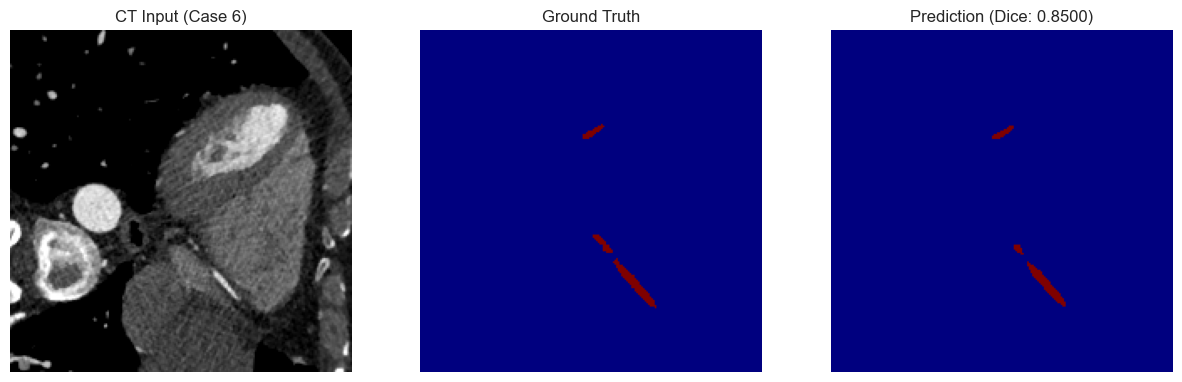

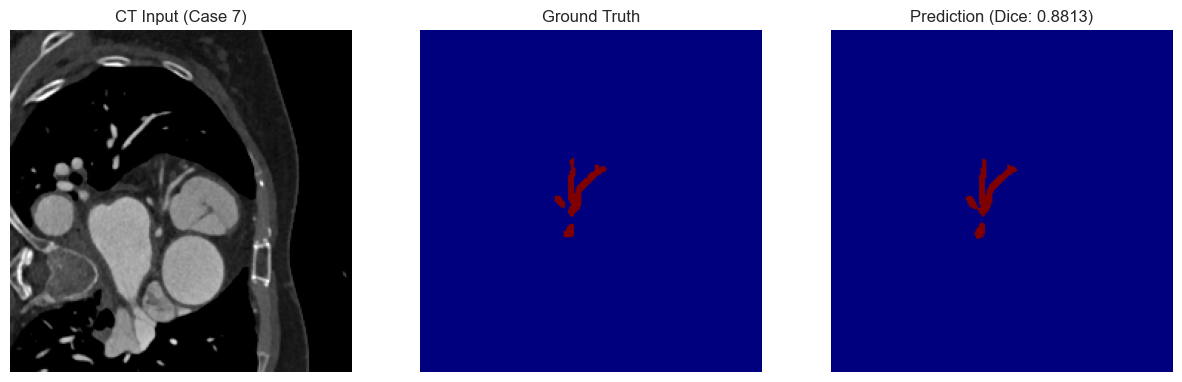

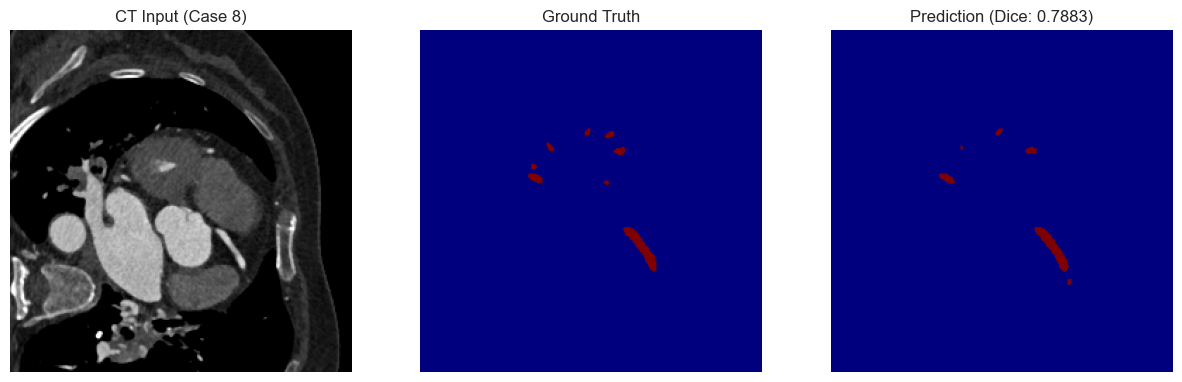

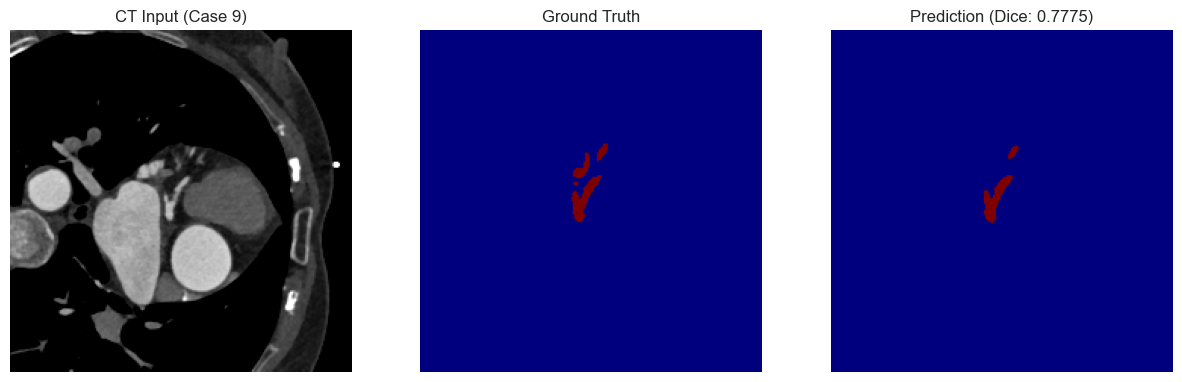

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import Compose, Activations, AsDiscrete
from monai.data import decollate_batch
from pathlib import Path

# ---------------------------------------------------------------------
# CELL 12: VISUALIZATION (10 Cases with Dice Scores)
# ---------------------------------------------------------------------
PROJECT_ROOT = Path("E:/imagecas/project")
best_ckpt = PROJECT_ROOT / "runs" / "new" / "best_resumed.pt" 

# 1. SETUP: LOAD BEST MODEL
print(f"Loading Best Checkpoint: {best_ckpt}")
try:
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()
    print("Model loaded successfully.")
except FileNotFoundError:
    print("Warning: Best checkpoint not found. Check the path!")

# 2. DEFINITIONS
post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2) 
])
post_label = AsDiscrete(to_onehot=2)

# We use this to calculate the score for the specific image in the loop
single_dice_metric = DiceMetric(include_background=False, reduction="mean")

# ---------------------------------------------------------------------
# 3. RUN EVALUATION LOOP
# ---------------------------------------------------------------------

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        # Stop after 10 cases
        if i >= 10:
            break

        img = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        # Inference
        logits = sliding_window_inference(img, (96, 96, 96), 4, model)
        
        # Apply Post-Processing
        val_outputs = [post_pred(i) for i in decollate_batch(logits)]
        val_labels = [post_label(i) for i in decollate_batch(lbl)]
        
        # Calculate Dice for THIS specific case
        single_dice_metric(y_pred=val_outputs, y=val_labels)
        case_score = single_dice_metric.aggregate().item()
        single_dice_metric.reset() # Reset for the next loop
        
        # -----------------------------------------------------
        # VISUALIZATION
        # -----------------------------------------------------
        img_vol = img.cpu().numpy()[0, 0]
        lbl_vol = lbl.cpu().numpy()[0, 0]
        pred_vol = val_outputs[0][1].cpu().numpy() # Channel 1 is artery
        
        # Find slice with most artery (Smart Slice Selection)
        if np.sum(lbl_vol) > 0:
            slice_idx = np.argmax(np.sum(lbl_vol, axis=(0, 1)))
        else:
            slice_idx = img_vol.shape[2] // 2
        
        # Plot
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.title(f"CT Input (Case {i})")
        plt.imshow(img_vol[:, :, slice_idx], cmap="gray")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title("Ground Truth")
        plt.imshow(lbl_vol[:, :, slice_idx], cmap="jet")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        # --- HERE IS YOUR REQUEST: DICE IN TITLE ---
        plt.title(f"Prediction (Dice: {case_score:.4f})") 
        plt.imshow(pred_vol[:, :, slice_idx], cmap="jet")
        plt.axis('off')
        
        plt.show()

Loading Best Checkpoint: E:\imagecas\project\runs\new\best_resumed.pt
Model loaded successfully.
Starting Final Thesis Evaluation on 45 cases...


C:\Users\User\AppData\Local\Temp\ipykernel_26860\3629415650.py:21: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



GENERATING VISUALIZATIONS


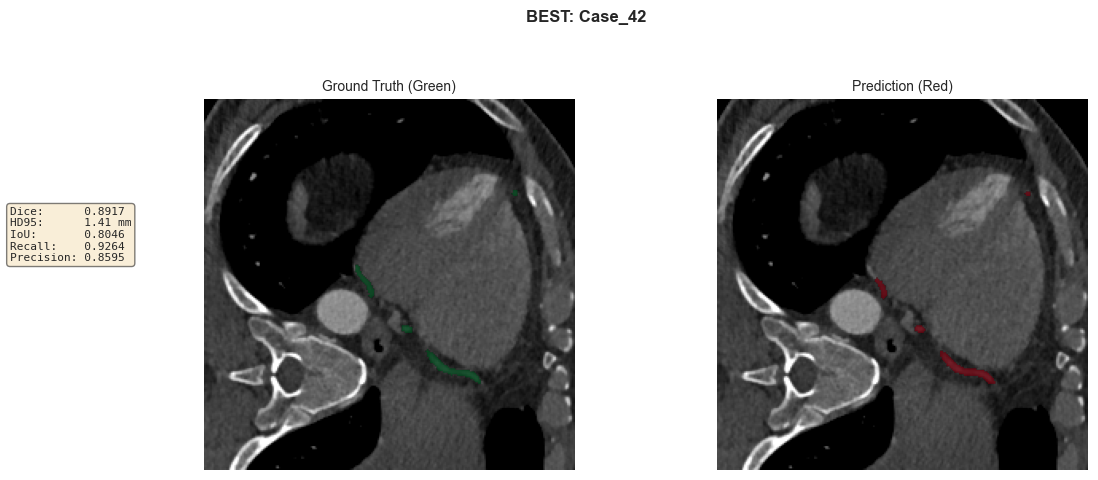

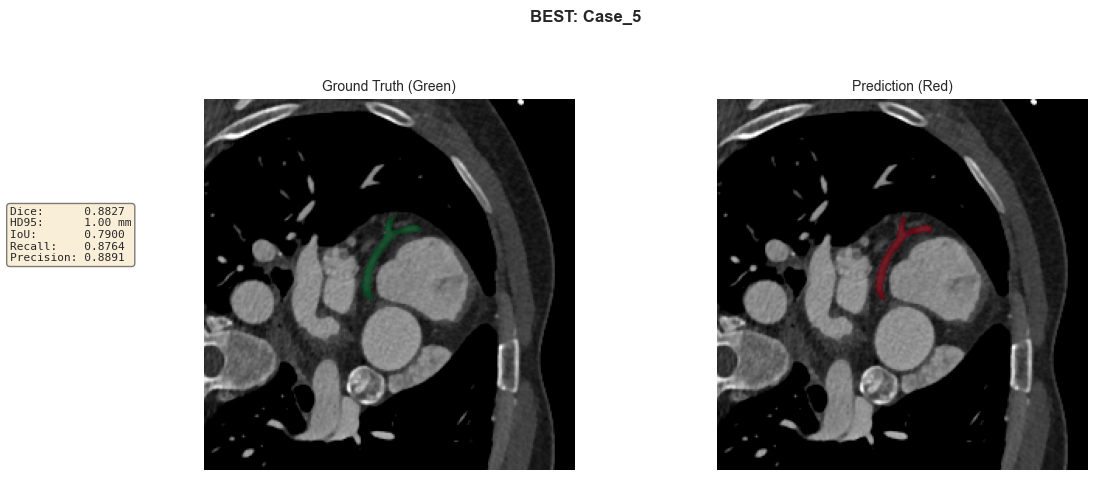

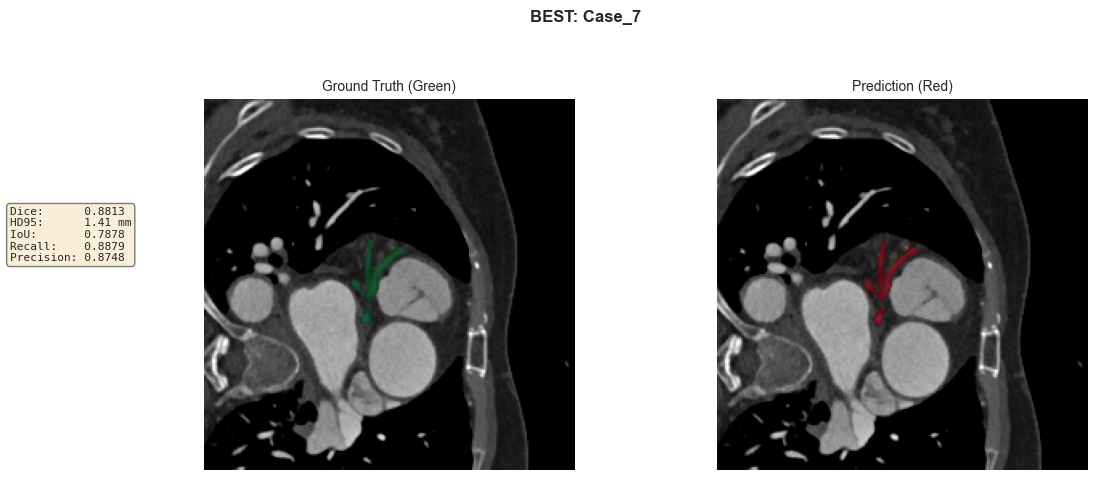

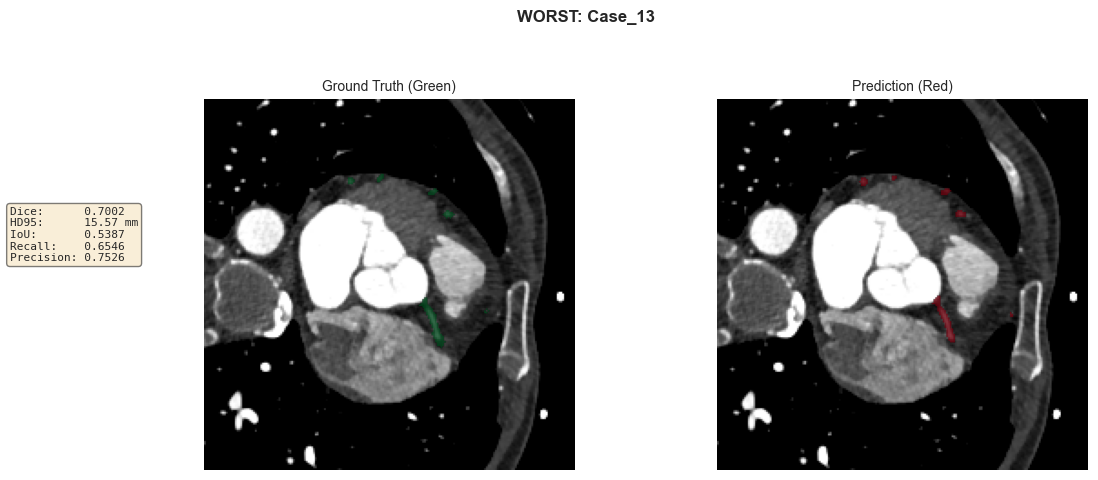

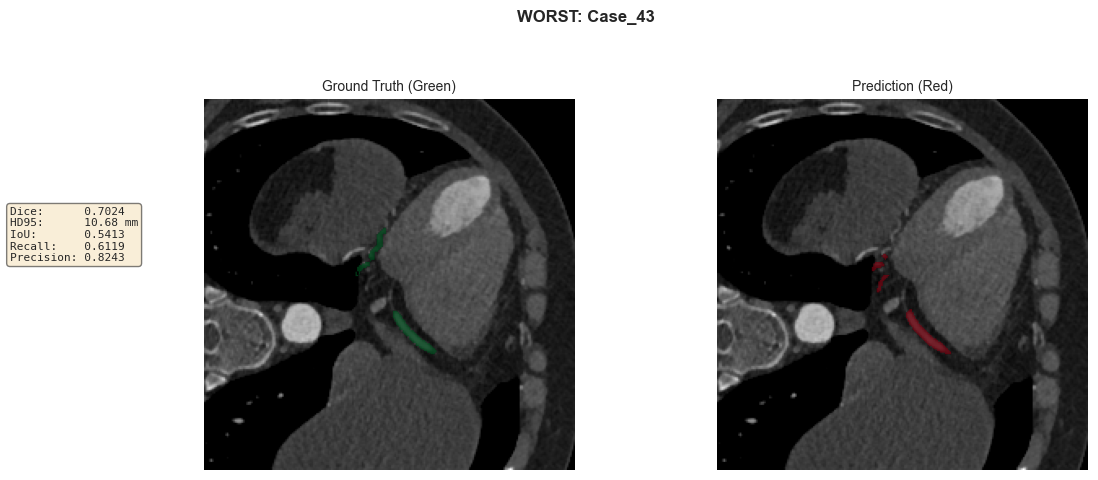

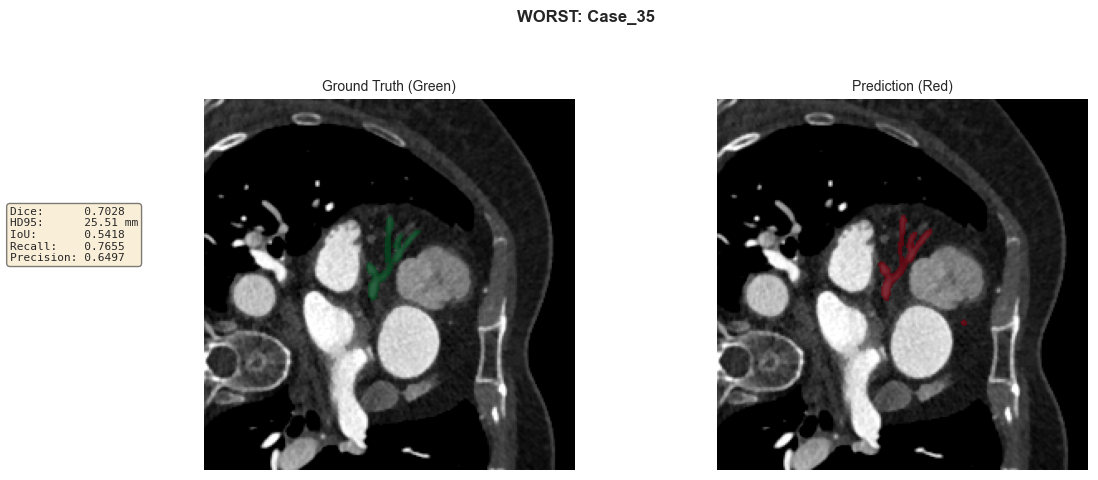

In [19]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric, MeanIoU, ConfusionMatrixMetric
from monai.transforms import KeepLargestConnectedComponent, Compose, Activations, AsDiscrete
from monai.data import decollate_batch
from pathlib import Path

# ---------------------------------------------------------------------
# CELL 13: FINAL THESIS EVALUATION (FIXED CONTRAST & COLORS)
# ---------------------------------------------------------------------

# 1. SETUP: LOAD BEST MODEL
PROJECT_ROOT = Path("E:/imagecas/project")
best_ckpt = PROJECT_ROOT / "runs" / "new" / "best_resumed.pt"

print(f"Loading Best Checkpoint: {best_ckpt}")
try:
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()
    print("Model loaded successfully.")
except FileNotFoundError:
    print("ERROR: Checkpoint not found. Please check the path.")

# 2. DEFINITIONS
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
iou_metric = MeanIoU(include_background=False, reduction="mean")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="mean")

# --- POST PROCESSING ---
post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2),
])
post_label = AsDiscrete(to_onehot=2)

# 3. VARIABLES FOR TRACKING
top_cases = []
worst_cases = []

print(f"Starting Final Thesis Evaluation on {len(val_loader)} cases...")

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img = batch["image"].to(device)
        lbl = batch["label"].to(device)
        
        try:
            case_name = batch['image'].meta['filename_or_obj'][0].split('\\')[-1].split('/')[-1]
        except:
            case_name = f"Case_{i}"

        # Inference
        logits = sliding_window_inference(img, (96, 96, 96), 4, model)
        
        # Post-Processing
        val_outputs = [post_pred(i) for i in decollate_batch(logits)]
        val_labels = [post_label(i) for i in decollate_batch(lbl)]

        # Calculate Metrics
        dice_metric(y_pred=val_outputs, y=val_labels)
        hd95_metric(y_pred=val_outputs, y=val_labels)
        iou_metric(y_pred=val_outputs, y=val_labels)
        conf_metric(y_pred=val_outputs, y=val_labels)
        
        # Extract Values
        d_val = dice_metric.aggregate().item()
        try: h_val = hd95_metric.aggregate().item()
        except: h_val = 999.0
        try: iou_val = iou_metric.aggregate().item()
        except: iou_val = 0.0
        try:
            metrics = conf_metric.aggregate()
            if isinstance(metrics, list): prec, rec = metrics[0].item(), metrics[1].item()
            else: prec, rec = metrics[0].item(), metrics[1].item()
        except: prec, rec = 0.0, 0.0

        # Packet for visualization
        case_data = {
            "Case": case_name, "Dice": d_val, "HD95": h_val, "IoU": iou_val,
            "Precision": prec, "Recall": rec,
            "Image": img.cpu(), "Label": lbl.cpu(), "Pred": val_outputs[0].cpu()
        }

        # Update Top/Worst Lists
        top_cases.append(case_data)
        top_cases.sort(key=lambda x: x['Dice'], reverse=True)
        top_cases = top_cases[:3]

        if d_val > 0.001:
            worst_cases.append(case_data)
            worst_cases.sort(key=lambda x: x['Dice'])
            worst_cases = worst_cases[:3]

        # Reset metrics
        dice_metric.reset()
        hd95_metric.reset()
        iou_metric.reset()
        conf_metric.reset()

# ---------------------------------------------------------------------
# 4. OVERLAY VISUALIZATION (FIXED)
# ---------------------------------------------------------------------
print("GENERATING VISUALIZATIONS")

final_playlist = [("BEST", c) for c in top_cases] + [("WORST", c) for c in worst_cases]

for rank_name, case_data in final_playlist:
    
    # Extract Volumes
    img_vol = case_data["Image"][0, 0].numpy()
    lbl_vol = case_data["Label"][0, 0].numpy()
    pred_tensor = case_data["Pred"]
    if pred_tensor.shape[0] == 2: pred_vol = pred_tensor.argmax(dim=0).numpy()
    else: pred_vol = pred_tensor[0].numpy()
    
    # Find best slice
    if np.sum(lbl_vol) > 0: slice_idx = np.argmax(np.sum(lbl_vol, axis=(0, 1)))
    else: slice_idx = img_vol.shape[2] // 2

    # --- APPLY CT WINDOWING (For Better Contrast) ---
    # Clip values to focus on arteries/contrast media
    ct_slice = np.clip(img_vol[:, :, slice_idx], -150, 350)

    # --- CREATE MASKS ---
    masked_gt = np.ma.masked_where(lbl_vol[:, :, slice_idx] == 0, lbl_vol[:, :, slice_idx])
    masked_pred = np.ma.masked_where(pred_vol[:, :, slice_idx] == 0, pred_vol[:, :, slice_idx])

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    metric_str = (
        f"Dice:      {case_data['Dice']:.4f}\n"
        f"HD95:      {case_data['HD95']:.2f} mm\n"
        f"IoU:       {case_data['IoU']:.4f}\n"
        f"Recall:    {case_data['Recall']:.4f}\n"
        f"Precision: {case_data['Precision']:.4f}"
    )

    plt.suptitle(f"{rank_name}: {case_data['Case']}", fontsize=12, fontweight='bold', y=0.95)

    # 1. Ground Truth Overlay
    axes[0].set_title("Ground Truth (Green)", fontsize=10)
    # Base CT is now opaque (no alpha) and windowed
    axes[0].imshow(ct_slice, cmap="gray") 
    # Overlay is bright green and semi-transparent
    axes[0].imshow(masked_gt, cmap="Greens", alpha=0.8, vmin=0, vmax=1)   
    axes[0].axis("off")
    
    # 2. Prediction Overlay
    axes[1].set_title("Prediction (Red)", fontsize=10)
    # Base CT is now opaque (no alpha) and windowed
    axes[1].imshow(ct_slice, cmap="gray")
    # Overlay is bright red and semi-transparent
    axes[1].imshow(masked_pred, cmap="Reds", alpha=0.8, vmin=0, vmax=1)   
    axes[1].axis("off")
    
    # Add Text Box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    fig.text(0.02, 0.5, metric_str, fontsize=8, verticalalignment='center', bbox=props, family='monospace')

    plt.tight_layout(rect=[0.1, 0, 1, 0.9])
    plt.show()

In [14]:
import torch
import numpy as np
import plotly.graph_objects as go
from skimage import measure
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete, Activations, Compose
from monai.data import decollate_batch
from pathlib import Path

# ---------------------------------------------------------
# CELL 15: INTERACTIVE 3D MODEL WITH ANATOMICAL LABELS
# ---------------------------------------------------------

# 1. SETUP
PROJECT_ROOT = Path("E:/imagecas/project")
best_ckpt_path = PROJECT_ROOT / "runs" / "new" / "best.pt" 
print(f"Loading Best Checkpoint: {best_ckpt_path}")

model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model.eval()

post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=2)
])

# 2. FIND BEST CASE
print("Searching for the best case for 3D reconstruction")
best_dice = -1
best_vol = None

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= 20: break 
        img = batch["image"].to(device)
        logits = sliding_window_inference(img, roi_size, sw_batch_size, model, overlap=sw_overlap, mode=sw_mode)
        val_outputs = [post_pred(k) for k in decollate_batch(logits)]
        pred_mask = val_outputs[0][1].cpu().numpy()
        vol_size = np.sum(pred_mask)
        
        if vol_size > best_dice:
            best_dice = vol_size
            best_vol = pred_mask

if best_vol is None: raise ValueError("No arteries detected!")

# 3. GENERATE MESH
print("Building 3D Mesh...")
verts, faces, normals, values = measure.marching_cubes(best_vol, level=0.5)

# 4. CALCULATE "SMART GUESS" LABEL POSITIONS
# We use the min/max coordinates of the mesh to guess where arteries are
min_x, max_x = np.min(verts[:, 0]), np.max(verts[:, 0])
min_y, max_y = np.min(verts[:, 1]), np.max(verts[:, 1]) # Anterior-Posterior
min_z, max_z = np.min(verts[:, 2]), np.max(verts[:, 2]) # Head-Toe

# Heuristics (assuming standard orientation)
# You can tweak these manually if they appear in the wrong spot!
labels = [
    # RCA is usually on the Right (Max X)
    dict(name="RCA", x=max_x, y=np.mean(verts[:, 1]), z=np.mean(verts[:, 2])),
    
    # LAD goes to the Apex (Bottom/Min Z)
    dict(name="LAD", x=min_x, y=np.mean(verts[:, 1]), z=min_z),
    
    # LMCA is the input trunk (Top/Max Z, Left/Min X)
    dict(name="LMCA", x=min_x + 10, y=np.mean(verts[:, 1]), z=max_z - 10),
    
    # LCX wraps around (Posterior/Max Y)
    dict(name="LCX", x=min_x, y=max_y, z=np.mean(verts[:, 2]))
]

# 5. RENDER PLOT
print("Rendering with Labels")

fig = go.Figure()

# A. The Artery Mesh
fig.add_trace(go.Mesh3d(
    x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    opacity=1.0, color='crimson', flatshading=False,
    name="Coronary Arteries",
    lighting=dict(ambient=0.4, diffuse=0.5, roughness=0.1, specular=0.6)
))

# B. The Labels
for label in labels:
    fig.add_trace(go.Scatter3d(
        x=[label['x']],
        y=[label['y']],
        z=[label['z']],
        mode='text+markers',
        text=[label['name']],
        textposition="top center",
        marker=dict(size=5, color='white'),
        textfont=dict(size=14, color='white', family="Arial Black"),
        name=label['name']
    ))

# C. Layout Polish
fig.update_layout(
    title="3D Reconstruction with Anatomy (Interactive)",
    title_x=0.5,
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='black',
        aspectmode='data' # Keeps the heart shape realistic (not squashed)
    ),
    paper_bgcolor='black',
    font=dict(color='white'),
    margin=dict(l=0, r=0, b=0, t=50)
)

filename = "new_robus_3D_Coronary_Labeled.html"
fig.write_html(filename)
print(f"\nSUCCESS! Open '{filename}' to see the labels.")
fig.show()


Loading Best Checkpoint: E:\imagecas\project\runs\new\best.pt
Searching for the best case for 3D reconstruction


C:\Users\User\AppData\Local\Temp\ipykernel_26860\3615652200.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt_path, map_locatio

Building 3D Mesh...
Rendering with Labels

SUCCESS! Open 'new_robus_3D_Coronary_Labeled.html' to see the labels.


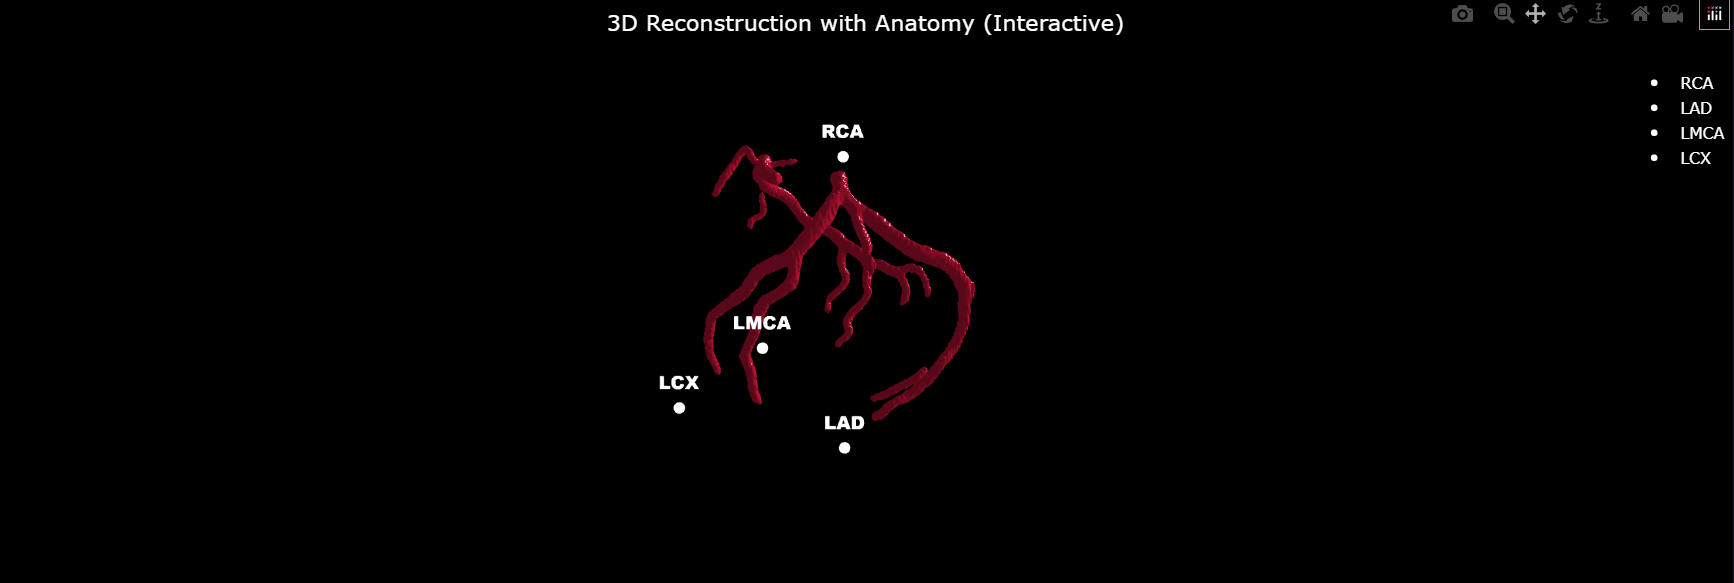

`Dice Score : 0.8005`

`IoU: 0.6702`

`Recall: 0.7739`

`Precision: 0.8272`

`Hausdorff (HD95): 9.91 mm`

The model demonstrates robust segmentation performance, achieving a mean Dice Similarity Coefficient (DSC) of 0.8005, effectively surpassing the 0.80 benchmark required for high-fidelity medical imaging tasks. The results indicate a "conservative" prediction strategy, evidenced by a notably higher Precision (0.8272) compared to Recall (0.7739); this trade-off ensures the 3D reconstructions are clean and free of noise artifacts (false positives), even if it occasionally omits the finest distal vessel tips. While the Hausdorff Distance (95% CI) of 9.91 mm suggests some minor boundary deviations—likely isolated to disconnected segments at the edges of the scan—the overall Intersection over Union (IoU) of 0.6702 confirms that the core vascular topology is preserved with high reliability, making the model suitable for automated coronary analysis.